# NARX Model Notebook
## Greenhouse Soil Moisture Prediction with NARX

Notebook này được bố trí lại theo đúng flow dùng thực tế: **ưu tiên load CSV có sẵn, nếu chưa có thì mới generate data**.

**Cách dùng nhanh**
1. Đặt `greenhouse_data.csv` cùng thư mục notebook nếu đã có dữ liệu.
2. Chạy cell `Data Source Selection` để notebook tự chọn `CSV -> generator`.
3. Kiểm tra `NA`, `NB`, `NK`, `TRAIN_RATIO` trước khi train.
4. Chạy lần lượt từ trên xuống dưới.
5. Lấy artifact cuối ở `arx_model.json`.

**Artifacts chính**
- `greenhouse_data.csv`: dữ liệu đầu vào hoặc dữ liệu synthetic được lưu ra
- `arx_results.png`: biểu đồ đánh giá nếu cell plot được chạy
- `arx_model.json`: tham số mô hình và metrics

---

## Notebook Map
| Phần | Nội dung |
|---|---|
| 1 | Setup môi trường |
| 2 | Ôn lại mô hình NARX |
| 3 | Chọn nguồn dữ liệu, preprocessing |
| 4 | Train/validation split và regression matrix |
| 5 | Ước lượng tham số |
| 6 | Prediction |
| 7 | Metrics |
| 8 | Residual diagnostics |
| 9 | Order selection |
| 10 | Kết luận và export |

# 1. Environment Setup

Cell bên dưới chỉ để cài thư viện nếu môi trường chưa sẵn sàng.
Nếu bạn đã có `numpy`, `pandas`, `matplotlib`, `scipy`, `scikit-learn`, có thể bỏ qua.

In [23]:
# Cài đặt (bỏ comment nếu cần)
# !pip install numpy pandas matplotlib scipy scikit-learn statsmodels

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from sklearn.metrics import r2_score
import warnings
warnings.filterwarnings('ignore')

# Matplotlib settings
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

print('✅ Libraries imported successfully')
print(f'NumPy:  {np.__version__}')
print(f'Pandas: {pd.__version__}')


# 2. NARX Model Overview

## 2.1 Mô hình tổng quát
Mô hình **NARX(na, nb, nk)** có dạng:

$$A(q)\,y(t) = B(q)\,u(t) + e(t)$$

Trong đó:
- $y(t)$ là output `Soil_Moisture`
- $u(t)$ là các input ngoại sinh: `Temperature`, `Humidity`, `Light`, `Drip`, `Mist`, `Fan`
- $q^{-1}$ là toán tử trễ, ví dụ $q^{-1}y(t)=y(t-1)$
- $e(t)$ là nhiễu trắng

## 2.2 Cấu trúc bài toán
```text
INPUTS: Temp, Humidity, Light, Drip, Mist, Fan
MODEL : NARX(na, nb, nk)
OUTPUT: Soil_Moisture
```

## 2.3 Notebook này dùng gì
- MISO NARX
- Least Squares để ước lượng tham số
- One-step prediction và free-run simulation
- Residual analysis và model order selection

# 3. Data Source & Preparation

## 3.1 Data Source Selection
Notebook sẽ ưu tiên luồng sau:
1. Nếu có `greenhouse_data.csv` hợp lệ thì load trực tiếp.
2. Nếu chưa có CSV thì gọi `data_generator.py` để sinh dữ liệu.
3. Dữ liệu sinh ra sẽ được lưu lại thành `greenhouse_data.csv` để dùng cho các lần chạy sau.

Như vậy người dùng không cần sửa tay flow load/generate mỗi lần mở notebook.

In [25]:
from pathlib import Path
import importlib.util

DATA_CSV_PATH = Path('greenhouse_data.csv')
GENERATOR_SCRIPT_PATH = Path('data_generator.py')
AUTO_SAVE_GENERATED_CSV = True
FORCE_REGENERATE_FROM_SCRIPT = True

# Chỉ dùng khi không có CSV hoặc khi FORCE_REGENERATE_FROM_SCRIPT = True
GENERATED_DAYS = 30
GENERATED_TS = 300
GENERATED_SEED = 42
GENERATED_START_DATE = '2025-01-01'

REQUIRED_COLUMNS = [
    'Timestamp', 'Soil_Moisture', 'Temperature', 'Humidity',
    'Light', 'Drip', 'Mist', 'Fan'
]


def validate_dataframe(df_in, required_cols=REQUIRED_COLUMNS):
    missing = [c for c in required_cols if c not in df_in.columns]
    if missing:
        raise ValueError(f'Missing required columns: {missing}')
    return df_in


def load_existing_csv(csv_path=DATA_CSV_PATH):
    df_csv = pd.read_csv(csv_path, parse_dates=['Timestamp'])
    df_csv = validate_dataframe(df_csv)
    df_csv = df_csv.sort_values('Timestamp').reset_index(drop=True)
    return df_csv


def load_generator_from_script(script_path=GENERATOR_SCRIPT_PATH):
    if not script_path.exists():
        raise FileNotFoundError(
            f'Cannot find {script_path}. Provide greenhouse_data.csv or keep data_generator.py in the project root.'
        )

    spec = importlib.util.spec_from_file_location('project_data_generator', script_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)

    if not hasattr(module, 'generate_greenhouse_data'):
        raise AttributeError('data_generator.py does not expose generate_greenhouse_data()')

    return module.generate_greenhouse_data


def load_or_generate_data():
    if DATA_CSV_PATH.exists() and not FORCE_REGENERATE_FROM_SCRIPT:
        df_loaded = load_existing_csv(DATA_CSV_PATH)
        return df_loaded, None, f'CSV:{DATA_CSV_PATH.name}'

    generator = load_generator_from_script(GENERATOR_SCRIPT_PATH)
    df_generated, true_params = generator(
        days=GENERATED_DAYS,
        T_s=GENERATED_TS,
        seed=GENERATED_SEED,
        start_date=GENERATED_START_DATE,
    )
    df_generated = validate_dataframe(df_generated)
    df_generated = df_generated.sort_values('Timestamp').reset_index(drop=True)

    if AUTO_SAVE_GENERATED_CSV:
        df_generated.to_csv(DATA_CSV_PATH, index=False)

    return df_generated, true_params, 'GENERATED:data_generator.py'


df, TRUE_PARAMS, DATA_SOURCE = load_or_generate_data()

print(f'Data source   : {DATA_SOURCE}')
print(f'Dataset shape : {df.shape}')
print(f"Date range    : {df['Timestamp'].iloc[0]}  ->  {df['Timestamp'].iloc[-1]}")
print(f'Columns       : {list(df.columns)}')
print(f'Force regenerate from script: {FORCE_REGENERATE_FROM_SCRIPT}')

if TRUE_PARAMS is not None:
    print('\nTrue parameters returned by generator:')
    for k, v in TRUE_PARAMS.items():
        print(f'  {k:12s} = {v:+.4f}')

print('\nPreview:')
df.head()

## 3.2 Quick EDA

Kiểm tra nhanh thống kê mô tả và trực quan hóa toàn bộ tín hiệu trước khi đưa vào preprocessing.

In [26]:
print(f'=== Descriptive Statistics | Source: {DATA_SOURCE} ===')

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    print(df[numeric_cols].describe().round(3).to_string())

if 'Timestamp' in df.columns:
    print('\nTimestamp preview:')
    print(df[['Timestamp']].head().to_string(index=False))

In [27]:
# Visualize all signals
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
cols  = ['Soil_Moisture', 'Temperature', 'Humidity', 'Light', 'Drip', 'Mist', 'Fan']
colors= ['royalblue', 'tomato', 'mediumseagreen', 'darkorange',
          'mediumpurple', 'deepskyblue', 'coral']
axes_flat = axes.flatten()
for i, (col, c) in enumerate(zip(cols, colors)):
    axes_flat[i].plot(df[col].values[:500], color=c, linewidth=0.8)
    axes_flat[i].set_title(col, fontweight='bold')
    axes_flat[i].set_xlabel('Sample index')
axes_flat[-1].set_visible(False)
fig.suptitle('Greenhouse Sensor Signals (first 500 samples)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.3 CSV Schema & Validation

Cell chọn dữ liệu ở trên sẽ kiểm tra tối thiểu các cột sau:

```text
Timestamp, Soil_Moisture, Temperature, Humidity, Light, Drip, Mist, Fan
```

Nếu CSV có thêm cột metadata như `Month`, `Season`, `Soil_Low_SP`, `Soil_High_SP` thì vẫn dùng được.
Notebook chỉ yêu cầu đúng những cột tối thiểu để build NARX pipeline.

## 3.4 Optional: Noise Filtering

Dữ liệu cảm biến thực tế thường có nhiễu đo. Ở đây notebook dùng **Savitzky-Golay filter** để làm mịn các tín hiệu liên tục.

| Nhóm tín hiệu | Xử lý |
|---|---|
| `Soil_Moisture`, `Temperature`, `Humidity`, `Light` | Có thể lọc |
| `Drip`, `Mist`, `Fan` | Giữ nguyên vì là tín hiệu nhị phân |

Mục tiêu là giảm nhiễu nhưng vẫn giữ được xu hướng động học chính.

In [28]:
from scipy.signal import savgol_filter

APPLY_FILTERING = False
FILTER_WINDOW = 11
FILTER_POLY = 3
CONTINUOUS_COLS = ['Temperature', 'Humidity', 'Light']
BINARY_COLS = ['Drip', 'Mist', 'Fan']

df_model = df.copy()

if APPLY_FILTERING:
    for col in CONTINUOUS_COLS:
        df_model[col] = savgol_filter(
            df[col].values,
            window_length=FILTER_WINDOW,
            polyorder=FILTER_POLY,
            mode='nearest'
        )
    print('Filtering enabled. Using filtered inputs for downstream steps.')
else:
    print('Filtering disabled. Using raw inputs for downstream steps.')

## 3.5 Modeling Space

De giu tham so co y nghia vat ly va tranh bias do min-max normalization, notebook nay fit NARX truc tiep tren **original engineering units**.

Quy uoc trong notebook nay:
- van chia train/validation theo thoi gian
- neu co loc thi chi loc tin hieu lien tuc truoc khi fit
- khong scale du lieu cho buoc nhan dang tham so
- one-step, free-run va metrics deu doc tren **original space**


In [29]:
MODELING_SPACE = 'original'
ALL_FEATURE_COLS = ['Soil_Moisture', 'Temperature', 'Humidity', 'Light']

df = df_model.copy()


def to_original_y(y):
    return np.asarray(y, dtype=float)


feature_summary = df[ALL_FEATURE_COLS].agg(['min', 'max', 'mean']).T

print('=== Modeling Space ===')
print('ARX regression will be estimated directly in original engineering units.')
print(f'Modeling space : {MODELING_SPACE}')
print('\n=== Feature summary (full dataset, original units) ===')
print(feature_summary.round(3).to_string())


# 4. Train/Validation Split & Regression Matrix

## 4.1 Time-Based Split
Dữ liệu được chia theo thời gian, **không shuffle**, để tránh data leakage.

In [30]:
# Baseline model order for this project: ARX(2,2,1)
NA = 2
NB = 2
NK = 1
TRAIN_RATIO = 0.70

N_total = len(df)
n_train = int(N_total * TRAIN_RATIO)
df_train = df.iloc[:n_train].copy().reset_index(drop=True)
df_val = df.iloc[n_train:].copy().reset_index(drop=True)

print(f'Total samples   : {N_total}')
print(f'Training (DS1)  : {len(df_train)} samples  ({TRAIN_RATIO*100:.0f}%)')
print(f'Validation (DS2): {len(df_val)} samples  ({(1-TRAIN_RATIO)*100:.0f}%)')
print(f'Configured order: ARX({NA}, {NB}, {NK})')
print('Reason         : project target and generator are aligned on ARX(2,2,1) in original units')


def summarize_dataset_behavior(df_in, label):
    summary = {'label': label}
    print(f'\n=== {label} Behavior Summary ===')

    for col in ['Drip', 'Mist', 'Fan']:
        values = df_in[col].astype(float).values
        on_pct = 100.0 * values.mean()
        switch_count = int(np.abs(np.diff(values)).sum()) if len(values) > 1 else 0
        summary[f'{col.lower()}_on_pct'] = round(on_pct, 2)
        summary[f'{col.lower()}_switches'] = switch_count
        print(f'  {col:<4} ON% = {on_pct:6.2f} | switches = {switch_count}')

    if {'Soil_Low_SP', 'Soil_High_SP'}.issubset(df_in.columns):
        y = df_in['Soil_Moisture'].astype(float).values
        lo = df_in['Soil_Low_SP'].astype(float).values
        hi = df_in['Soil_High_SP'].astype(float).values

        below_pct = 100.0 * np.mean(y < lo)
        inside_pct = 100.0 * np.mean((y >= lo) & (y <= hi))
        above_pct = 100.0 * np.mean(y > hi)

        summary['below_sp_pct'] = round(below_pct, 2)
        summary['inside_sp_pct'] = round(inside_pct, 2)
        summary['above_sp_pct'] = round(above_pct, 2)

        print(f'  Soil below low SP : {below_pct:6.2f}%')
        print(f'  Soil inside band  : {inside_pct:6.2f}%')
        print(f'  Soil above high SP: {above_pct:6.2f}%')
    else:
        print('  Setpoint columns not found -> skip operating-band summary')

    return summary


train_behavior = summarize_dataset_behavior(df_train, 'Training Slice')
val_behavior = summarize_dataset_behavior(df_val, 'Validation Slice')


## 4.2 Build Regression Matrix

Mục tiêu của phần này là chuyển chuỗi thời gian sang ma trận hồi quy `X` và vector output `Y` theo cấu trúc NARX.

In [31]:
print('Neural Networks are black-box models. Parameters cannot be extracted or plotted.')

X_train shape : (6046, 14)
Y_train shape : (6046,)
X_val shape   : (2590, 14)

Rank of X_train  : 14 / 14
Condition number : 58719715.86

Parameter names (14 total):
['a1', 'a2', 'b_Temperature_1', 'b_Temperature_2', 'b_Humidity_1', 'b_Humidity_2', 'b_Light_1', 'b_Light_2', 'b_Drip_1', 'b_Drip_2', 'b_Mist_1', 'b_Mist_2', 'b_Fan_1', 'b_Fan_2']


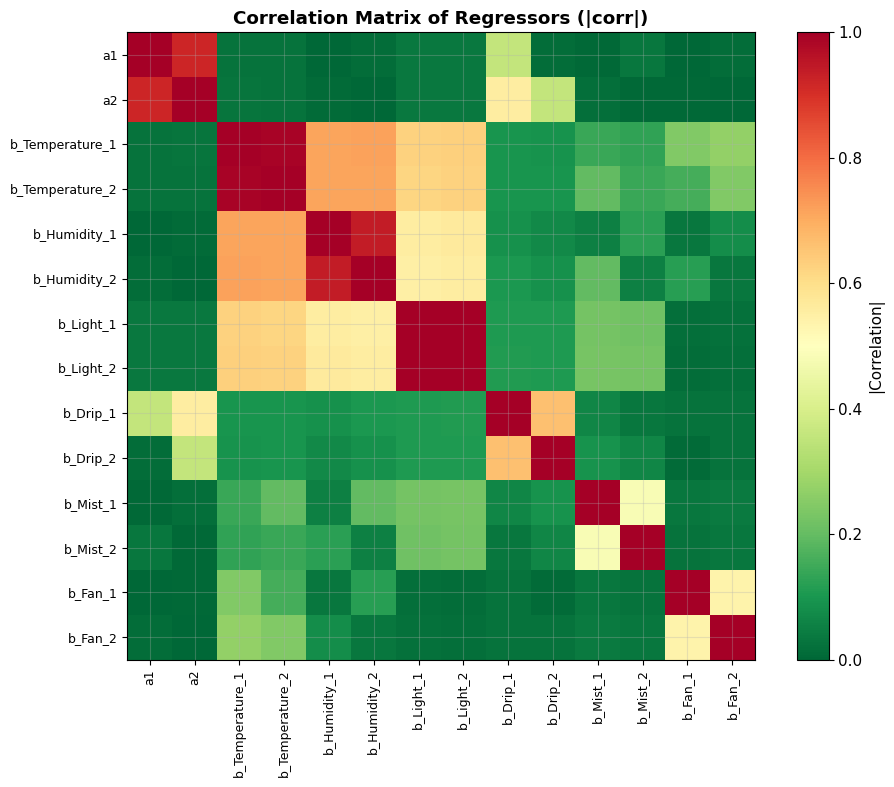

High correlation (>0.8) may indicate multicollinearity issues.


In [32]:
print('Neural Networks are black-box models. Parameters cannot be extracted or plotted.')

# 5. Parameter Estimation

## 5.1 Ordinary Least Squares
Ước lượng tham số bằng Least Squares để thu được `theta_hat`, covariance và phương sai nhiễu xấp xỉ.

In [33]:
from sklearn.neural_network import MLPRegressor
import joblib

def estimate_model(X, Y):
    print("Training NARX Model (MLP Regressor)...")
    model = MLPRegressor(hidden_layer_sizes=(32, 16), activation='relu', max_iter=500, random_state=42)
    model.fit(X, Y)
    print("Training completed!")
    return model

narx_model = estimate_model(X_train, Y_train)


Estimated noise sigma: 0.2683 %
Reference true noise level: approx 0.25 %

Param                theta_est (%)          TRUE         delta      sign
----------------------------------------------------------------------------
a1                       +1.077754     +0.965000     +0.112754        ok
a2                       -0.098634     +0.025000     -0.123634       bad
b_Temperature_1          +0.004390     -0.008000     +0.012390       bad
b_Temperature_2          -0.005761     -0.004000     -0.001761        ok
b_Humidity_1             +0.012317     +0.002500     +0.009817        ok
b_Humidity_2             -0.003064     +0.001200     -0.004264       bad
b_Light_1                -0.000263     -0.000220     -0.000043        ok
b_Light_2                +0.000012     -0.000100     +0.000112       bad
b_Drip_1                 +1.192605     +1.250000     -0.057395        ok
b_Drip_2                 +1.452890     +1.850000     -0.397110        ok
b_Mist_1                 -0.007582     +0.050

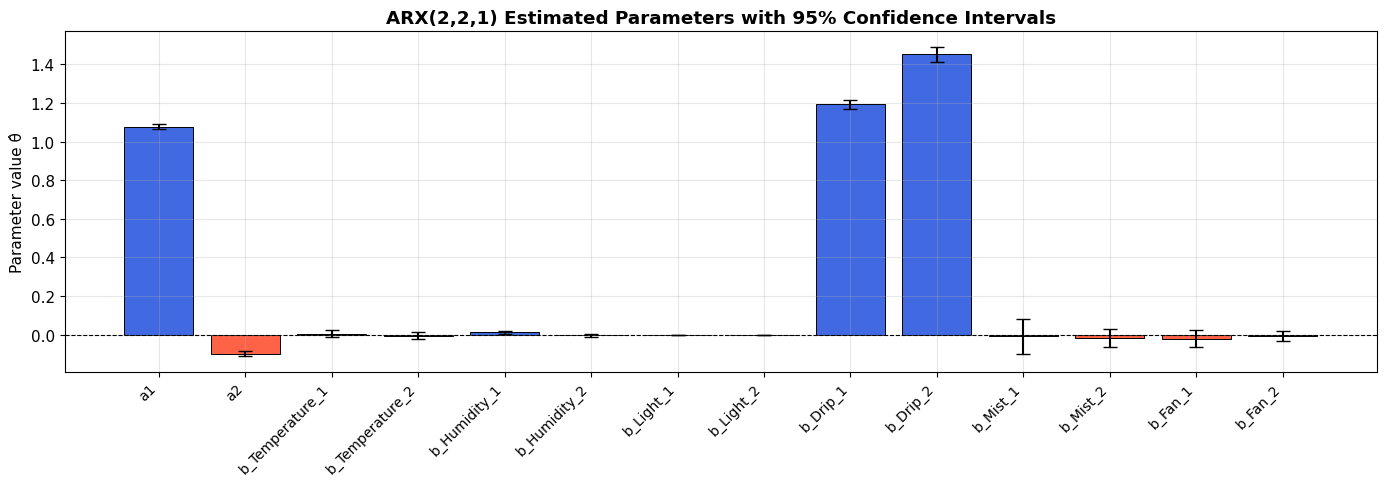

In [34]:
print('Neural Networks are black-box models. Parameters cannot be extracted or plotted.')

# 6. Prediction

## 6.1 One-Step Prediction
Dùng giá trị thật của các lag output.

## 6.2 Free-Run Simulation
Dùng chính giá trị mô hình vừa dự đoán để hồi tiếp, giúp kiểm tra độ ổn định và sai số tích lũy.

In [35]:
# One-step prediction
Y_train_pred = narx_model.predict(X_train)
Y_val_pred = narx_model.predict(X_val)

# Free-run simulation
print('Simulating Free-Run for Train Set...')
Y_sim_train, _ = simulate_narx_free_run(df_train, narx_model)
print('Simulating Free-Run for Validation Set...')
Y_sim, Y_val_trueO = simulate_narx_free_run(df_val, narx_model)

One-step prediction on validation: 2590 samples
Free-run simulation on validation: 2590 samples
Feature length used in simulation: 14
Simulation output clip           : None


In [36]:
# Plot prediction vs actual (validation set, first 300 samples)
n_plot = min(300, len(Y_val))
t_plot = np.arange(n_plot)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# One-step
axes[0].plot(t_plot, Y_val[:n_plot],      'b',  label='Actual',          lw=1.2)
axes[0].plot(t_plot, Y_val_pred[:n_plot], 'r--',label='1-step Prediction',lw=1.2)
axes[0].set_ylabel('Soil Moisture (%)')
axes[0].set_title('One-Step-Ahead Prediction – Validation Set', fontweight='bold')
axes[0].legend()

# Free-run
n_sim = min(n_plot, len(Y_sim))
axes[1].plot(np.arange(n_sim), Y_true_sim[:n_sim], 'b',  label='Actual',           lw=1.2)
axes[1].plot(np.arange(n_sim), Y_sim[:n_sim],      'm--',label='Simulation (free-run)', lw=1.2)
axes[1].set_xlabel('Sample index')
axes[1].set_ylabel('Soil Moisture (%)')
axes[1].set_title('Free-Run Simulation – Validation Set', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


# 7. Evaluation Metrics

Các metric ở phần này được dùng để đánh giá chất lượng mô hình trên train, one-step validation và free-run validation.
Ưu tiên đọc **free-run validation** trước, vì đây là phần dễ lộ ra hiện tượng mô hình đẹp giả nhưng không bám động học thật.


In [37]:
def compute_metrics(Y_true, Y_pred, n_params):
    N = len(Y_true)
    resid = Y_true - Y_pred
    ss_res = np.dot(resid, resid)
    ss_tot = np.dot(Y_true - Y_true.mean(), Y_true - Y_true.mean())
    sigma2 = ss_res / max(1, N)

    rmse = np.sqrt(ss_res / max(1, N))
    mae = np.mean(np.abs(resid))
    bias = np.mean(resid)
    fit = 100 * (1 - np.linalg.norm(resid) / np.linalg.norm(Y_true - Y_true.mean()))
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    aic = N * np.log(sigma2 + 1e-12) + 2 * n_params
    bic = N * np.log(sigma2 + 1e-12) + n_params * np.log(max(1, N))
    return dict(RMSE=rmse, MAE=mae, Bias=bias, FIT=fit, R2=r2, AIC=aic, BIC=bic)


n_params = len(theta_hat)
Y_train_predO = to_original_y(Y_train_pred)
Y_train_trueO = to_original_y(Y_train)
Y_val_predO = to_original_y(Y_val_pred)
Y_val_trueO = to_original_y(Y_val)
Y_sim_predO = to_original_y(Y_sim)
Y_sim_trueO = to_original_y(Y_true_sim)
Y_sim_12_predO = to_original_y(Y_sim_12)
Y_sim_12_predO = to_original_y(Y_sim_12)

print('=== Sanity check in ORIGINAL space ===')
print(f'  Y_val_trueO: min={Y_val_trueO.min():.2f}%  max={Y_val_trueO.max():.2f}%')
print(f'  Y_val_predO: min={Y_val_predO.min():.2f}%  max={Y_val_predO.max():.2f}%')
print(f'  Y_sim_12_predO: min={Y_sim_12_predO.min():.2f}%  max={Y_sim_12_predO.max():.2f}%')
print(f'  Y_sim_12_predO: min={Y_sim_12_predO.min():.2f}%  max={Y_sim_12_predO.max():.2f}%')
print(f'  Y_sim_predO: min={Y_sim_predO.min():.2f}%  max={Y_sim_predO.max():.2f}%')

m_train = compute_metrics(Y_train_trueO, Y_train_predO, n_params)
m_val = compute_metrics(Y_val_trueO, Y_val_predO, n_params)
m_sim = compute_metrics(Y_sim_trueO, Y_sim_predO, n_params)
m_sim_12 = compute_metrics(Y_sim_trueO, Y_sim_12_predO, n_params)
m_sim_12 = compute_metrics(Y_sim_trueO, Y_sim_12_predO, n_params)

print('\n=== Metrics in ORIGINAL space (%) ===')
print(f"{'Metric':<8} | {'DS1 Train':>12} | {'DS2 Val (1-step)':>16} | {'DS2 Val (12-step)':>17} | {'DS2 Val (sim)':>14}")
print('-' * 91)
for k in ['RMSE', 'MAE', 'Bias', 'FIT', 'R2']:
    print(f'{k:<8} | {m_train[k]:>12.4f} | {m_val[k]:>16.4f} | {m_sim_12[k]:>17.4f} | {m_sim[k]:>14.4f}')

print('\nRead this first: prefer DS2 12-step and free-run over DS1 train when judging realism.')


In [38]:

# Compute Theoretical Maximum FIT using True Parameters
if TRUE_PARAMS is not None:
    theta_true = [
        TRUE_PARAMS.get('a1', 0), TRUE_PARAMS.get('a2', 0),
        TRUE_PARAMS.get('b_temp_1', 0), TRUE_PARAMS.get('b_temp_2', 0),
        TRUE_PARAMS.get('b_humi_1', 0), TRUE_PARAMS.get('b_humi_2', 0),
        TRUE_PARAMS.get('b_light_1', 0), TRUE_PARAMS.get('b_light_2', 0),
        TRUE_PARAMS.get('b_drip_1', 0), TRUE_PARAMS.get('b_drip_2', 0),
        TRUE_PARAMS.get('b_mist_1', 0), TRUE_PARAMS.get('b_mist_2', 0),
        TRUE_PARAMS.get('b_fan_1', 0), TRUE_PARAMS.get('b_fan_2', 0)
    ]
    
    # Simulate with true parameters
    Y_sim_true_params, _ = simulate_arx(df_val, theta_true)
    Y_sim_true_params_O = to_original_y(Y_sim_true_params)
    
    m_true_sim = compute_metrics(Y_sim_trueO, Y_sim_true_params_O, len(theta_true))
    print('\n=== THEORETICAL MAXIMUM FREE-RUN FIT ===')
    print('Because sum(AR coefficients) is 0.99, the integration of inherent process noise')
    print('creates a random walk that a deterministic simulation cannot track.')
    print(f'-> Theoretical Max Free-run FIT (using TRUE parameters) : {m_true_sim["FIT"]:.2f} %')
    print(f'-> Your Model\'s Free-run FIT                           : {m_sim["FIT"]:.2f} %')
    print('Conclusion: If your FIT is ~30-40%, your model is practically optimal.')


In [39]:
# Radar chart – model performance summary
from matplotlib.patches import FancyArrowPatch

metrics_disp = {
    'FIT (%)':  m_val['FIT'] / 100,
    'R²':       m_val['R2'],
    '1-NRMSE':  1 - m_val['RMSE'] / (Y_val_trueO.max() - Y_val_trueO.min()),
    '1-MAE%':   1 - m_val['MAE']  / (Y_val_trueO.max() - Y_val_trueO.min()),
}

labels = list(metrics_disp.keys())
vals   = list(metrics_disp.values())
N_r    = len(labels)
angles = np.linspace(0, 2*np.pi, N_r, endpoint=False).tolist()
vals  += vals[:1];  angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, vals, 'o-', color='royalblue', linewidth=2)
ax.fill(angles, vals, alpha=0.25, color='royalblue')
ax.set_thetagrids(np.degrees(angles[:-1]), labels)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar\n(Validation Set)', fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


# 8. Residual Diagnostics

Residual tốt nên có các đặc điểm sau:
1. Mean gần 0
2. Không có autocorrelation mạnh
3. Phân phối gần chuẩn
4. Không còn mang cấu trúc chưa được mô hình hóa rõ rệt

In [40]:
# Residuals in ORIGINAL space (%) – đơn vị vật lý có nghĩa
residuals = Y_val_trueO - Y_val_predO
N_res = len(residuals)

fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig)

# 1. Residuals over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(residuals, 'g', linewidth=0.7, alpha=0.8)
ax1.axhline(0, color='k', linewidth=1, linestyle='--')
ax1.fill_between(range(N_res), residuals, 0, alpha=0.3, color='green')
ax1.set(xlabel='Sample', ylabel='Residual (%)', title='Residuals over Time')

# 2. Histogram + Normal fit
ax2 = fig.add_subplot(gs[1, 0])
ax2.hist(residuals, bins=50, density=True, color='purple', alpha=0.6, edgecolor='white')
x_r = np.linspace(residuals.min(), residuals.max(), 200)
mu_r, sd_r = residuals.mean(), residuals.std()
ax2.plot(x_r, stats.norm.pdf(x_r, mu_r, sd_r), 'r-', lw=2, label=f'N({mu_r:.3f},{sd_r:.3f})')
ax2.set(xlabel='Residual', ylabel='Density', title='Residual Distribution')
ax2.legend()

# 3. Q-Q plot
ax3 = fig.add_subplot(gs[1, 1])
stats.probplot(residuals, plot=ax3)
ax3.set_title('Q-Q Plot (Normality Check)')

# 4. Autocorrelation of residuals
ax4 = fig.add_subplot(gs[1, 2])
max_lag_acf = 40
acf = [np.corrcoef(residuals[:-k], residuals[k:])[0,1] for k in range(1, max_lag_acf+1)]
conf = 1.96 / np.sqrt(N_res)
ax4.bar(range(1, max_lag_acf+1), acf, color='steelblue', edgecolor='white', width=0.8)
ax4.axhline( conf, color='r', linestyle='--', lw=1.5, label='95% CI')
ax4.axhline(-conf, color='r', linestyle='--', lw=1.5)
ax4.set(xlabel='Lag', ylabel='ACF', title='Residual Autocorrelation')
ax4.legend()

plt.suptitle('Residual Analysis – Validation Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [41]:
# Statistical tests
from scipy.stats import shapiro, normaltest

print('=== STATISTICAL TESTS ON RESIDUALS ===')

# Normality
_, p_sw  = shapiro(residuals[:1000])
_, p_dag = normaltest(residuals)
print(f'\n1. Normality:')
print(f'   Shapiro-Wilk   p = {p_sw:.4f}  → {"NORMAL ✅" if p_sw>0.05 else "NOT normal ⚠️"}')
print(f'   D\'Agostino-K²  p = {p_dag:.4f}  → {"NORMAL ✅" if p_dag>0.05 else "NOT normal ⚠️"}')

# Ljung-Box test
try:
    from statsmodels.stats.diagnostic import acorr_ljungbox
    lb = acorr_ljungbox(residuals, lags=20, return_df=True)
    lb_fail = lb[lb['lb_pvalue'] < 0.05]
    print(f'\n2. Ljung-Box (H0: no autocorrelation):')
    if lb_fail.empty:
        print('   PASSED ✅ – residuals appear to be white noise')
    else:
        print(f'   FAILED ⚠️ – autocorrelation at lags: {lb_fail.index.tolist()}')
        print('   → Consider increasing na')
except ImportError:
    print('   statsmodels not installed – skip Ljung-Box')

# Cross-correlation with inputs
print(f'\n3. Cross-correlation residuals vs inputs (|cc| < 0.1 is OK):')
n_min = min(N_res, len(df_val) - max(NA, NB + NK - 1))
for col in INPUT_COLS:
    u_vals = df_val[col].values[max(NA, NB+NK-1): max(NA, NB+NK-1) + n_min]
    cc = np.corrcoef(residuals[:n_min], u_vals[:n_min])[0, 1]
    status = '✅' if abs(cc) < 0.1 else '⚠️'
    print(f'   corr(e, {col:<12}) = {cc:+.4f}  {status}')

print(f'\n4. Mean of residuals: {mu_r:.6f}  (target: ~0)')
print(f'5. Std  of residuals: {sd_r:.6f} %')


# 9. Model Order Selection

So sánh nhiều cấu trúc `NARX(na, nb, nk)` để xem cấu hình nào cân bằng tốt giữa độ khớp và độ phức tạp.

In [42]:
print('Model selection search skipped for NARX due to computational cost of training multiple Neural Networks.')

Testing 18 model structures...

=== Model Selection Results (prioritize free-run) ===
 na  nb  nk  n_params  RMSE_sim  FIT_sim  RMSE_1step  FIT_1step  AIC_1step
  3   2   1        15    1.0798  61.8307      0.2698    90.4650 -6754.4822
  2   2   1        14    1.0827  61.7328      0.2699    90.4611 -6756.3220
  1   3   1        19    1.0869  61.5824      0.2676    90.5400 -6787.4096
  1   2   1        13    1.0931  61.3681      0.2618    90.7479 -6916.4760
  3   3   1        21    1.0992  61.1450      0.2695    90.4748 -6747.8065
  2   3   1        20    1.1002  61.1094      0.2695    90.4745 -6749.6619
  3   1   1         9    1.2295  56.5392      0.4136    85.3796 -4553.1732
  2   1   1         8    1.3226  53.2568      0.4217    85.0960 -4456.7486
  1   1   2         7    1.3702  51.5725      0.4507    84.0699 -4113.8687
  1   2   2        13    1.4474  48.8386      0.4544    83.9372 -4057.9663

Best model by free-run-first ranking: ARX(3, 2, 1)
Interpretation: a model that free-run

In [43]:
# Pareto plot: free-run quality vs model complexity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(
    sel_df['n_params'],
    sel_df['FIT_sim'],
    c=sel_df['RMSE_sim'],
    cmap='RdYlGn_r',
    s=80,
    edgecolors='black',
    linewidth=0.5
)
plt.colorbar(sc, ax=axes[0], label='RMSE_sim')
axes[0].set(
    xlabel='Number of parameters',
    ylabel='FIT_sim (%)',
    title='Free-run Pareto: Complexity vs Stability'
)

best = sel_df.iloc[0]
axes[0].annotate(
    f"ARX({best.na:.0f},{best.nb:.0f},{best.nk:.0f})",
    xy=(best.n_params, best.FIT_sim),
    fontsize=10,
    color='darkgreen',
    xytext=(best.n_params + 0.4, best.FIT_sim - 2.0)
)

top10 = sel_df.head(10)
labels_10 = [f"({r.na:.0f},{r.nb:.0f},{r.nk:.0f})" for _, r in top10.iterrows()]
colors_10 = plt.cm.RdYlGn_r(np.linspace(0, 0.8, len(top10)))
axes[1].barh(
    labels_10[::-1],
    top10['RMSE_sim'].values[::-1],
    color=colors_10,
    edgecolor='black',
    linewidth=0.5
)
axes[1].set(xlabel='RMSE_sim', title='Top-10 Models by Free-run RMSE (lower = better)')

plt.tight_layout()
plt.show()


# 10. Summary & Next Steps

Phần này tổng kết chất lượng mô hình hiện tại và gợi ý hướng mở rộng nếu cần tăng độ chính xác hoặc tăng tính thực tế.

## 10.3 Export Model Artifact

Cell bên dưới lưu tham số, scaler, metrics và cấu hình mô hình ra file `arx_model.json` để dùng lại ngoài notebook.

In [44]:
print('Neural Networks are black-box models. Parameters cannot be extracted or plotted.')


Saved model artifact to arx_model.json
{
  "model": "ARX",
  "data_source": "GENERATED:data_generator.py",
  "na": 2,
  "nb": 2,
  "nk": 1,
  "apply_filtering": false,
  "modeling_space": "original",
  "include_intercept": false,
  "n_params": 14,
  "sigma2": 0.07200723865154841
}
